# Day 12: Drift Detection (Evidently AI)

Two monitoring scenarios, each reusing feature-engineering.

1. **Churn features**: the Day 9 feature logic, computed at an earlier
   cutoff (reference) vs. the Day 9 cutoff (current).
2. **Demand features**: the Day 2 daily aggregates, split into year one
   vs. year two of the same series.

In [1]:
import sys
sys.path.insert(0, "..")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.features.churn_labeling import build_churn_features
from src.monitoring.drift_detection import run_drift_report, extract_drift_summary, summarize_drift, recommend_retraining

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 20)

In [ ]:
raw = pd.read_csv("../data/processed/customer_sales.csv")
raw["invoice_date"] = pd.to_datetime(raw["invoice_date"])

ref_features = build_churn_features(raw, cutoff=pd.Timestamp("2011-06-01"))
cur_features = build_churn_features(raw, cutoff=pd.Timestamp("2011-09-10"))

cols = ["recency_days", "frequency", "monetary", "avg_order_value", "tenure_days", "monetary_per_day"]
snapshot = run_drift_report(ref_features, cur_features, cols)
summary = extract_drift_summary(snapshot)
overall = summarize_drift(snapshot)
summary

2026-06-22 09:20:16,822 [INFO] Built churn features for 4908 customers as of 2011-06-01


2026-06-22 09:20:18,147 [INFO] Built churn features for 5256 customers as of 2011-09-10


,column,method,value,drifted
0,avg_order_value,Wasserstein distance (normed),0.010873,False
1,frequency,Wasserstein distance (normed),0.051128,False
2,monetary,Wasserstein distance (normed),0.022728,False
3,monetary_per_day,Wasserstein distance (normed),0.027522,False
4,recency_days,Wasserstein distance (normed),0.271678,True
5,tenure_days,Wasserstein distance (normed),0.479057,True


## Churn features, June vs. September 2011

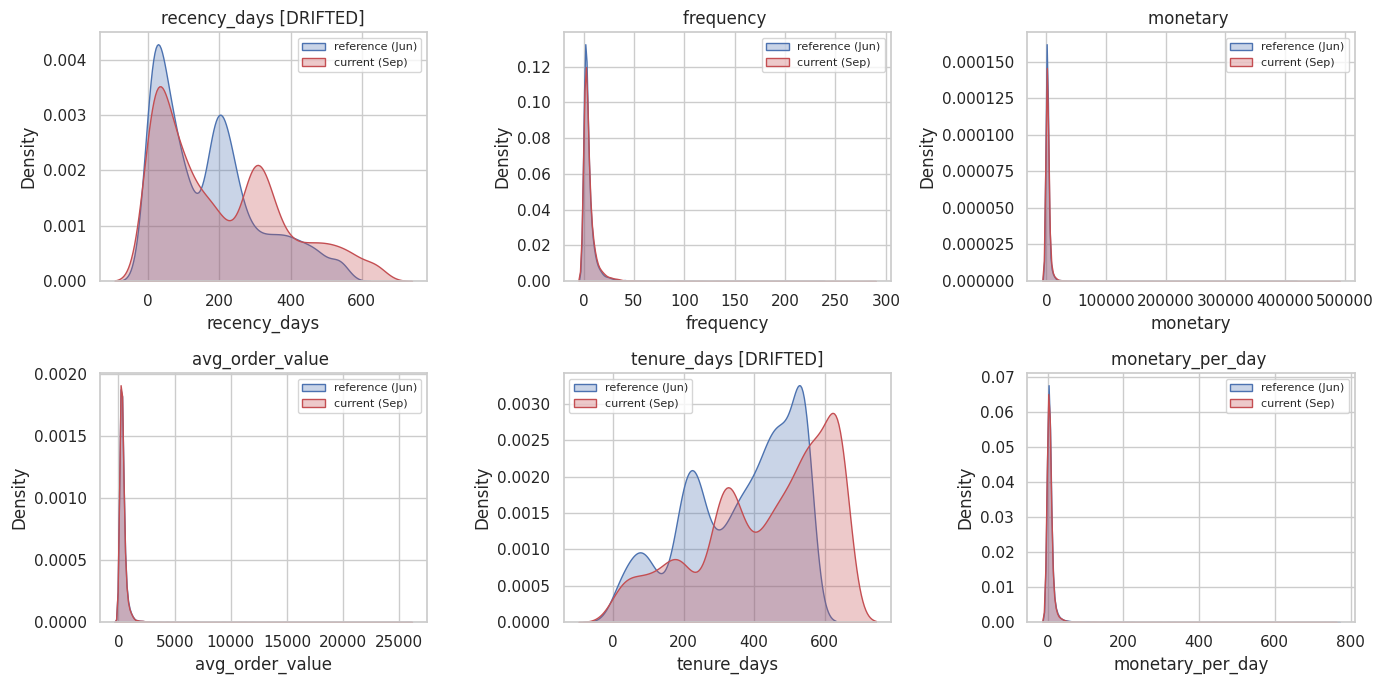

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.flat, cols):
    sns.kdeplot(ref_features[col], ax=ax, label="reference (Jun)", color="#4C72B0", fill=True, alpha=0.3)
    sns.kdeplot(cur_features[col], ax=ax, label="current (Sep)", color="#C44E52", fill=True, alpha=0.3)
    drifted = summary.set_index("column").loc[col, "drifted"]
    ax.set_title(f"{col} {'[DRIFTED]' if drifted else ''}")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Demand features, year one vs. year two

In [ ]:
daily = pd.read_csv("../data/features/demand_daily_flagged.csv")
daily["date"] = pd.to_datetime(daily["date"])
daily = daily[~daily["is_partial_day"]]
split = pd.Timestamp("2010-12-01")
ref_demand = daily[daily["date"] < split]
cur_demand = daily[daily["date"] >= split]

demand_cols = ["revenue", "quantity", "n_invoices", "n_customers"]
demand_snapshot = run_drift_report(ref_demand, cur_demand, demand_cols)
demand_summary = extract_drift_summary(demand_snapshot)
demand_overall = summarize_drift(demand_snapshot)
demand_summary

,column,method,value,drifted
0,n_customers,K-S p_value,0.989600,False
1,n_invoices,K-S p_value,0.830930,False
2,quantity,K-S p_value,0.559049,False
3,revenue,K-S p_value,0.229236,False


In [6]:
print(f"Mean revenue: year 1 = {ref_demand['revenue'].mean():.0f}, year 2 = {cur_demand['revenue'].mean():.0f} "
      f"(+{(cur_demand['revenue'].mean()/ref_demand['revenue'].mean()-1)*100:.0f}%)")
print(f"Drifted columns: {demand_overall['n_drifted']}/{len(demand_cols)}")

Mean revenue: year 1 = 25747, year 2 = 28037 (+9%)
Drifted columns: 0.0/4


## Retraining recommendations

In [7]:
print(f"Churn model retrain recommended: {recommend_retraining(overall)} (drifted share: {overall['drifted_share']:.0%})")
print(f"Forecast model retrain recommended: {recommend_retraining(demand_overall)} (drifted share: {demand_overall['drifted_share']:.0%})")

Churn model retrain recommended: False (drifted share: 33%)
Forecast model retrain recommended: False (drifted share: 0%)
